In [49]:
import numpy as np
import matplotlib.pyplot as plt

In [50]:
#~~~BAI1~~~
gay_nhieu = {"is", "a", "the", "for", "of", "and", "an", "to", "in"}
cau = [
    "Python is a popular programming language for AI technology",
    "Machine learning technology models require large amounts of data",
    "The new smartphone features an advanced AI technology chip",
    "Cloud computing technology allows developers to deploy data globally",
    "The striker scored a beautiful goal in the final sports match",
    "Playing basketball sports requires good physical health and teamwork",
    "The tennis player won the sports championship match",
    "Regular sports exercise and swimming are great for health"]

In [51]:
vocab = sorted({w for s in cau for w in s.lower().split() if w not in gay_nhieu})
def to_vector(s):
       v = np.zeros(len(vocab))
       for w in s.lower().split():
              if w in vocab:
                     v[vocab.index(w)]+= 1
       return v
X = np.array([to_vector(s) for s in cau])

In [52]:
print(X.shape, end = "\n\n") 
# ma trận X gồm có các hàng và cột
# mỗi hàng đại diện cho mỗi câu trong cau
# mỗi cột đại diện cho mỗi từ xuất hiện trong câu đó
# giá trị mỗi ô là số lần xuất hiện của từ trong câu

(8, 47)



In [53]:
Tb_cot= np.mean(X, axis=0)
print("~~~~Minh họa broadcasting~~~~")
print("Shape của X", X.shape)
print("Shape của Tb_cot", Tb_cot.shape)
X_moi= X-Tb_cot
print("Shape của ma trận kết quả X_moi", X_moi.shape)
print(X_moi)

~~~~Minh họa broadcasting~~~~
Shape của X (8, 47)
Shape của Tb_cot (47,)
Shape của ma trận kết quả X_moi (8, 47)
[[-0.125  0.75  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.25  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.25   0.875 -0.125 -0.125 -0.125 -0.25  -0.125 -0.125 -0.125
  -0.125 -0.125  0.875  0.875  0.875 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.5   -0.125 -0.125 -0.125  0.5   -0.125 -0.125]
 [-0.125 -0.25  -0.125  0.875 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125  0.75  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.25  -0.125  0.875  0.875  0.875 -0.25   0.875 -0.125 -0.125
  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.125
  -0.5   -0.125 -0.125 -0.125  0.5   -0.125 -0.125]
 [ 0.875  0.75  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.875 -0.125
  -0.125 -0.25  -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.125 -0.125
  -0.125 -0.25  -0.125 -0.125 -0.125 -0.125 -0.25  -0.125  0.87

In [54]:
def cosine_similarity(X, Y= None):
       if Y is None:
              Y=X
       Xn = X / np.linalg.norm(X, axis=1 , keepdims= True)
       Yn = Y / np.linalg.norm(Y, axis=1 , keepdims= True)
       return Xn @ Yn.T
print(cosine_similarity(X), end ="\n\n")

[[1.         0.14433757 0.3086067  0.14433757 0.         0.
  0.         0.        ]
 [0.14433757 1.         0.13363062 0.25       0.         0.
  0.         0.        ]
 [0.3086067  0.13363062 1.         0.13363062 0.         0.
  0.         0.        ]
 [0.14433757 0.25       0.13363062 1.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         1.         0.13363062
  0.3086067  0.14285714]
 [0.         0.         0.         0.         0.13363062 1.
  0.14433757 0.26726124]
 [0.         0.         0.         0.         0.3086067  0.14433757
  1.         0.15430335]
 [0.         0.         0.         0.         0.14285714 0.26726124
  0.15430335 1.        ]]



In [55]:
def semantic_search(query, top_k= 3):
      q = to_vector(query).reshape(1, -1)
      sims = cosine_similarity(X, q).flatten()
      idx = np.argsort(sims) [-top_k:][::-1]
      return [(cau[i], round(float(sims[i]),3)) for i in idx]

In [56]:
query = "Python developers use cloud computing to train data for Artificial Intelligence and deploy applications globally"
print("top 3 cau giong cau query nhat")
result = semantic_search(query)
for sen, score in result:
      print(sen, score, sep = " " , end ="\n")

top 3 cau giong cau query nhat
Cloud computing technology allows developers to deploy data globally 0.802
Python is a popular programming language for AI technology 0.154
Machine learning technology models require large amounts of data 0.134


Nhận xét:

-Các cặp giống nhau nhất là những cặp cùng chủ đề(chia sẽ nhiều từ vựng giống nhau hơn)
nên vector của chúng có hướng gần nhau hơn nên điểm Cosine_similarity cao.

-Các cặp khác nhau là những cặp không cùng chủ đề(không chia sẻ từ vựng chung) nên tích
vô hướng của 2 vector bằng 0 dẫn đến Cosine_similarity bằng 0.

-Kết quả hoàn toàn khớp với dự đoán khi ta phân loại theo chủ đề hay mắt thường.

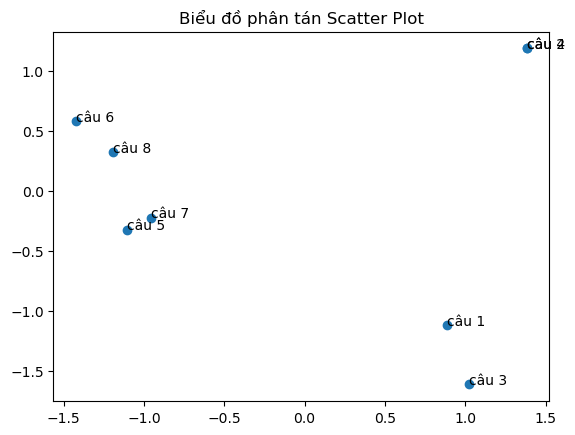

In [57]:
Xc = X - X.mean(axis=0)
U,S,Vt= np.linalg.svd(Xc, full_matrices=False)
coords = U[:,:2] * S[:2]

x = coords[:, 0]
y = coords[:, 1]

plt.title("Biểu đồ phân tán Scatter Plot")
plt.scatter(x,y)

nhan = [f"câu {i+1}" for i in range (len(x))]
for i in range (len(x)):
       plt.annotate(nhan[i], (x[i], y[i]))
plt.show()

Nhận xét:

-Bằng cách loại bỏ các từ gây nhiễu và gia tăng trọng số của các từ khóa chính, Thuật toán SVD đã
tìm ra được trục chính chia các câu theo chủ đề.

-Bởi vì các các câu 1,2,3,4 cùng chia sẻ một chủ đề về công nghệ, cùng chia sẻ một số từ chung 
nên khi vẽ biểu đồ phân tán các câu đó nằm về phía dương của trục hoành.

-Ngược lại các câu 5,6,7,8 cùng chung chủ đề về thể thao, cùng chia sẻ một số từ chung về chủ đề 
nên khi vẽ biểu đồ phân tán tọa độ của các câu nằm về chiều âm của trục hoành.